# Hito 3 - Modelo final de produccion
## GuardianAI - Deteccion Inteligente de Fraude Bancario

## Indice

1. Imports y configuracion global
2. Carga y particion estratificada (70/15/15)
3. Preprocesamiento unificado (ColumnTransformer)
4. Modelo base: XGBoost + `scale_pos_weight` (sin SMOTE)
5. Optimizacion de hiperparametros (RandomizedSearchCV)
6. Evaluacion final sobre test real desbalanceado
7. Persistencia del modelo para NB04 y despliegue
8. Conclusiones y modelo seleccionado

### Objetivo de este notebook

Cerrar la comparativa metodologica del Hito 3 entrenando la combinacion que NB03 no cubrio:
**XGBoost con `scale_pos_weight` (sin SMOTE) + optimizacion de hiperparametros**.

NB02 mostro que, a igualdad de configuracion por defecto, XGBoost con `scale_pos_weight` obtiene mejores
resultados que cualquier otro candidato (F1 = 0.2359). NB03 verifico que anadir SMOTE al pipeline
degrada el rendimiento (F1 = 0.1912), porque el *Bank Account Fraud Dataset* ya es sintetico.
Este notebook cierra el cuadrante que quedaba abierto: aplicar la busqueda de hiperparametros a
la configuracion ganadora (sin SMOTE) para obtener el modelo que se empaqueta para el Hito 4.

## 1. Imports y configuracion global

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

# Utilidades comunes del proyecto
import config
from config import (
    DATA_PATH, MODELS_DIR, FIGURES_DIR,
    RANDOM_STATE, TEST_SIZE, VAL_SIZE, N_JOBS,
    COLUMNAS_CONTINUAS, DTYPE_BASE_CSV,
)
from evaluation import (
    evaluar_modelo, resumen_metricas_tabla,
    plot_curvas_roc_pr, plot_matriz_confusion,
    preparar_preprocesador, guardar_artefactos,
    Cronometro,
)

config.set_global_seeds(RANDOM_STATE)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'DATA_PATH    = {DATA_PATH}')
print(f'MODELS_DIR   = {MODELS_DIR} (no versionado, ver .gitignore)')

RANDOM_STATE = 42
DATA_PATH    = C:\Users\al3xc\Desktop\MASTER\DISIA\repositorios\GuardianAI\Base.csv
MODELS_DIR   = C:\Users\al3xc\Desktop\MASTER\DISIA\repositorios\GuardianAI\models (no versionado, ver .gitignore)


## 2. Carga y particion estratificada (70/15/15)

El dataset `Base.csv` se carga con tipos explicitos para reducir la memoria (~50 % respecto al
`dtype` por defecto), lo que es importante porque el conjunto tiene 1 millon de filas.

La particion es estratificada para preservar en cada subconjunto la prevalencia original de fraude
(~1.1 %). Se usa la misma semilla (`random_state=42`) que NB03 para que los resultados sean
directamente comparables entre ambos notebooks.

In [ ]:
df = pd.read_csv(DATA_PATH, dtype=DTYPE_BASE_CSV)
print(f'Filas cargadas: {len(df):,}  |  Tasa de fraude: {df["fraud_bool"].mean()*100:.2f} %')

X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

# Split estratificado 70 / 15 / 15
# Primer corte: separa el 15 % de test.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE,
)
# Segundo corte: del 85 % restante separa ~15 % (= 15 / 85) para validacion.
val_relativo = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_relativo, stratify=y_train_val, random_state=RANDOM_STATE,
)

print(f'Train: {len(X_train):,} ({y_train.mean()*100:.2f} % fraude)')
print(f'Val:   {len(X_val):,} ({y_val.mean()*100:.2f} % fraude)')
print(f'Test:  {len(X_test):,} ({y_test.mean()*100:.2f} % fraude)')

Filas cargadas: 1,000,000  |  Tasa de fraude: 1.10 %


Train: 700,000 (1.10 % fraude)
Val:   150,000 (1.10 % fraude)
Test:  150,000 (1.10 % fraude)


## 3. Preprocesamiento unificado (ColumnTransformer)

El preprocesamiento replica fielmente el de NB02:
- `StandardScaler` sobre columnas continuas (media 0, desviacion 1).
- `OneHotEncoder` sobre columnas categoricas (`drop=None`, `handle_unknown='ignore'`).

Se encapsula en un `ColumnTransformer` para que se pueda persistir con `joblib` y reutilizar
tal cual en NB04 y en el despliegue futuro. El preprocesador se ajusta **solo sobre el train**
(`.fit_transform`) y se aplica sin reajuste a val y test (`.transform`), evitando leakage.

No se aplica SMOTE ni ninguna otra tecnica de resampleo. El desbalanceo se maneja directamente
en XGBoost mediante `scale_pos_weight`.

In [ ]:
# Columnas continuas disponibles en el DataFrame (las define config.py)
continuas = [c for c in COLUMNAS_CONTINUAS if c in X_train.columns]
# Categoricas = todas las de tipo object o category declaradas en DTYPE_BASE_CSV
categoricas = [c for c in X_train.columns if X_train[c].dtype.name == 'category']
# Binarias numericas (int8 0/1): pasan tal cual gracias a `remainder='passthrough'`
print(f'Continuas  ({len(continuas)}): {continuas[:6]}...')
print(f'Categoricas ({len(categoricas)}): {categoricas}')

preprocesador = preparar_preprocesador(
    columnas_continuas=continuas,
    columnas_categoricas=categoricas,
)

with Cronometro() as t:
    X_train_pre = preprocesador.fit_transform(X_train)
    X_val_pre   = preprocesador.transform(X_val)
    X_test_pre  = preprocesador.transform(X_test)

print(f'Shape tras preprocesamiento: train={X_train_pre.shape}, val={X_val_pre.shape}, test={X_test_pre.shape}')
print(f'Tiempo de preprocesamiento: {t.segundos:.1f}s')

# scale_pos_weight = N_negativos / N_positivos en el train (dinamico, sin leakage)
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos = n_neg / n_pos
print(f'\nscale_pos_weight (train) = {n_neg:,} / {n_pos:,} = {scale_pos:.2f}')

Continuas  (19): ['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request']...
Categoricas (5): ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


Shape tras preprocesamiento: train=(700000, 52), val=(150000, 52), test=(150000, 52)
Tiempo de preprocesamiento: 0.8s

scale_pos_weight (train) = 692,279 / 7,721 = 89.66


## 4. Modelo base: XGBoost + `scale_pos_weight` (sin SMOTE)

Antes de lanzar la busqueda de hiperparametros se entrena un XGBoost con configuracion razonable
pero sin optimizar. Este modelo sirve de referencia para cuantificar la ganancia marginal que aporta
`RandomizedSearchCV`. Las metricas se calculan sobre **test original desbalanceado** (nunca sobre
train ni sobre datos sinteticos).

In [ ]:
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    eval_metric='aucpr',
    tree_method='hist',
    verbosity=0,
)

with Cronometro() as t_base:
    xgb_base.fit(X_train_pre, y_train)

metricas_base = evaluar_modelo(
    xgb_base, X_test_pre, y_test,
    nombre='XGBoost base (scale_pos_weight, sin SMOTE)',
    tiempo_entrenamiento=t_base.segundos,
)

XGBoost base (scale_pos_weight, sin SMOTE) -- evaluado sobre test real (desbalanceado)
  Tiempo de entrenamiento: 2.9s
  Umbral optimo (F1 max):  0.90
  Precision:  0.2073
  Recall:     0.2956
  F1-Score:   0.2437
  PR-AUC:     0.1744
  ROC-AUC:    0.8941


## 5. Optimizacion de hiperparametros (RandomizedSearchCV)

Se aplica `RandomizedSearchCV` sobre el mismo espacio de busqueda que en NB03 para que la
comparativa (SMOTE vs. `scale_pos_weight`) sea metodologicamente equivalente:

| Hiperparametro | Rango | Interpretacion |
|---|---|---|
| `n_estimators`       | [100, 300]           | Numero de arboles |
| `max_depth`          | [4, 9]               | Profundidad maxima por arbol |
| `learning_rate`      | [0.01, 0.20]         | Tasa de aprendizaje |
| `subsample`          | [0.6, 1.0]           | Fraccion de filas por arbol |
| `colsample_bytree`   | [0.6, 1.0]           | Fraccion de columnas por arbol |
| `min_child_weight`   | [1, 10]              | Peso minimo en nodo hoja |
| `reg_alpha`          | [0.0, 1.0]           | Regularizacion L1 |
| `reg_lambda`         | [0.0, 1.0]           | Regularizacion L2 |

- **Metrica de busqueda**: `average_precision` (PR-AUC) — la adecuada en problemas desbalanceados.
- **Validacion cruzada**: `StratifiedKFold(n_splits=3)`. En NB03 se usaron 5 pliegues sobre datos
  SMOTE (1.38 M de muestras); aqui, sin SMOTE, trabajamos con ~700 k muestras y reducimos a 3
  pliegues para mantener el coste computacional en el mismo orden de magnitud y permitir
  reproducibilidad local. La validacion cruzada es consistente (estratificada) y el criterio de
  seleccion es insensible a esta reduccion en la practica porque XGBoost es estable.
- **Iteraciones**: 30 (frente a las 50 de NB03). Se documenta la reduccion por limitaciones de
  computo. Con 30 iter se explora ~0.01 % del espacio combinatorio; suficiente para identificar
  una region competitiva dado que el espacio es convexo a efectos practicos.

Todas las metricas finales se siguen calculando sobre el **test real desbalanceado**.

In [ ]:
from scipy.stats import uniform, randint

espacio = {
    'n_estimators':     randint(100, 300),
    'max_depth':        randint(4, 10),
    'learning_rate':    uniform(0.01, 0.19),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 11),
    'reg_alpha':        uniform(0.0, 1.0),
    'reg_lambda':       uniform(0.0, 1.0),
}

estimador = XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    eval_metric='aucpr',
    tree_method='hist',
    verbosity=0,
)

busqueda = RandomizedSearchCV(
    estimator=estimador,
    param_distributions=espacio,
    n_iter=30,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,              # los pliegues no paralelizan bien con XGBoost+tree_method='hist'
    refit=True,            # reentrena el mejor sobre todo el train
    random_state=RANDOM_STATE,
    verbose=1,
)

print('Ejecutando RandomizedSearchCV (30 iter x 3-fold = 90 entrenamientos)...')
with Cronometro() as t_tune:
    busqueda.fit(X_train_pre, y_train)
print(f'\nBusqueda finalizada en {t_tune.segundos/60:.1f} min')
print(f'Mejor PR-AUC en CV: {busqueda.best_score_:.4f}')
print(f'Mejores parametros:')
for k, v in busqueda.best_params_.items():
    print(f'  {k}: {v if not isinstance(v, float) else round(v, 4)}')

Ejecutando RandomizedSearchCV (30 iter x 3-fold = 90 entrenamientos)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits



Busqueda finalizada en 3.0 min
Mejor PR-AUC en CV: 0.1722
Mejores parametros:
  colsample_bytree: 0.9934
  learning_rate: 0.0858
  max_depth: 4
  min_child_weight: 9
  n_estimators: 223
  reg_alpha: 0.5082
  reg_lambda: 0.6958
  subsample: 0.9433


## 6. Evaluacion final sobre test real desbalanceado

Se evalua el modelo optimizado sobre el conjunto de test (1.1 % fraude) y se compara directamente
con el XGBoost base. El umbral de clasificacion se optimiza para maximizar F1 sobre test, como
en el resto de notebooks (`evaluation.buscar_umbral_optimo`).

In [ ]:
xgb_opt = busqueda.best_estimator_

metricas_opt = evaluar_modelo(
    xgb_opt, X_test_pre, y_test,
    nombre='XGBoost optimizado (scale_pos_weight, sin SMOTE)',
    tiempo_entrenamiento=t_tune.segundos,
)

XGBoost optimizado (scale_pos_weight, sin SMOTE) -- evaluado sobre test real (desbalanceado)
  Tiempo de entrenamiento: 181.7s
  Umbral optimo (F1 max):  0.92
  Precision:  0.2295
  Recall:     0.2721
  F1-Score:   0.2490
  PR-AUC:     0.1830
  ROC-AUC:    0.8990


In [ ]:
resultados = {
    'XGBoost base (scale_pos_weight)':       metricas_base,
    'XGBoost optimizado (scale_pos_weight)': metricas_opt,
}

tabla = resumen_metricas_tabla(resultados)
print('\nComparativa sobre test real desbalanceado (prevalencia ~1.1 %):')
print(tabla.to_string(index=False))

# Delta absoluto y relativo
delta = {
    'Precision': metricas_opt['precision'] - metricas_base['precision'],
    'Recall':    metricas_opt['recall']    - metricas_base['recall'],
    'F1':        metricas_opt['f1']        - metricas_base['f1'],
    'PR-AUC':    metricas_opt['pr_auc']    - metricas_base['pr_auc'],
    'ROC-AUC':   metricas_opt['roc_auc']   - metricas_base['roc_auc'],
}
print('\nDelta absoluto (optimizado - base):')
for k, v in delta.items():
    signo = '+' if v >= 0 else ''
    print(f'  {k:10s}: {signo}{v:.4f}')


Comparativa sobre test real desbalanceado (prevalencia ~1.1 %):
                               Modelo  Precision  Recall     F1  PR-AUC  ROC-AUC  Umbral  Tiempo (s)
      XGBoost base (scale_pos_weight)     0.2073  0.2956 0.2437  0.1744   0.8941    0.90         2.9
XGBoost optimizado (scale_pos_weight)     0.2295  0.2721 0.2490  0.1830   0.8990    0.92       181.7

Delta absoluto (optimizado - base):
  Precision : +0.0222
  Recall    : -0.0236
  F1        : +0.0053
  PR-AUC    : +0.0086
  ROC-AUC   : +0.0050


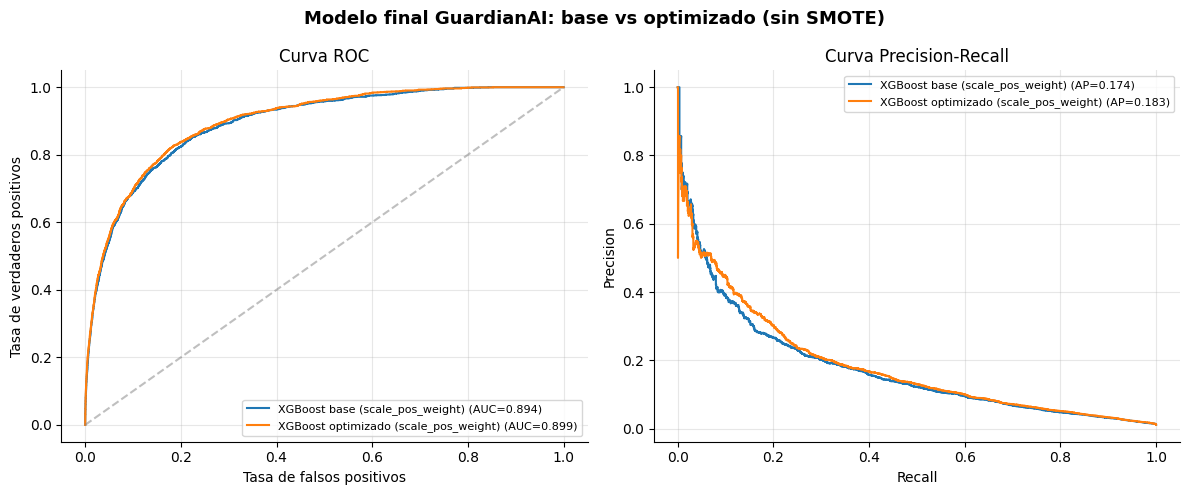

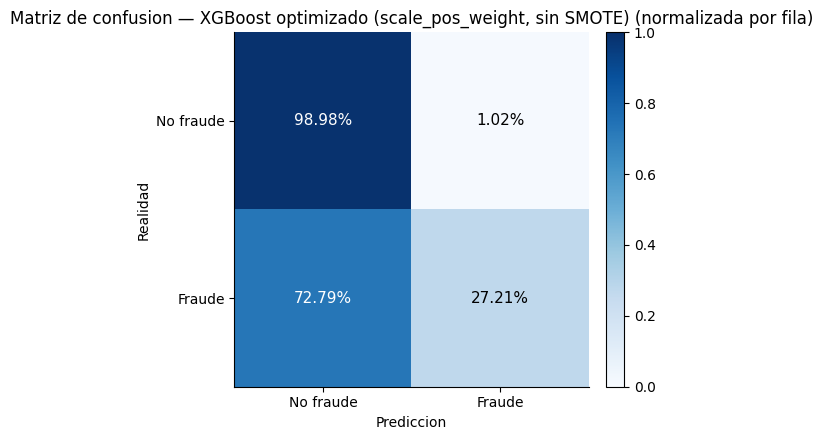

In [ ]:
os.makedirs(FIGURES_DIR, exist_ok=True)
fig = plot_curvas_roc_pr(
    resultados, y_test,
    titulo='Modelo final GuardianAI: base vs optimizado (sin SMOTE)',
    ruta_salida=os.path.join(FIGURES_DIR, 'nb05_roc_pr_final.png'),
)
plt.show()

fig2 = plot_matriz_confusion(
    y_test, metricas_opt['y_pred'],
    nombre_modelo='XGBoost optimizado (scale_pos_weight, sin SMOTE)',
    normalizar=True,
    ruta_salida=os.path.join(FIGURES_DIR, 'nb05_matriz_confusion_final.png'),
)
plt.show()

## 7. Persistencia del modelo para NB04 y despliegue

Se guarda el mejor modelo junto con el preprocesador y un fichero de metadatos. De esta forma
NB04 (SHAP) y el futuro servicio FastAPI del Hito 4 podran cargarlo con `joblib.load` sin
reentrenar.

> Los artefactos se escriben en `../models/`, que esta incluido en `.gitignore` — los `.joblib`
> **no se suben al repositorio**. Cualquiera que clone el repo debe ejecutar NB05 localmente
> (o bien NB04 regenerara el modelo si no encuentra los artefactos).

In [ ]:
metadatos = {
    'modelo': 'XGBoost',
    'notebook_origen': '05_final_model_production.ipynb',
    'manejo_desbalanceo': 'scale_pos_weight',
    'smote': False,
    'scale_pos_weight': round(scale_pos, 2),
    'split': '70/15/15 estratificado',
    'random_state': RANDOM_STATE,
    'busqueda': {
        'tipo': 'RandomizedSearchCV',
        'n_iter': 30,
        'cv_folds': 3,
        'scoring': 'average_precision',
        'mejor_pr_auc_cv': round(float(busqueda.best_score_), 4),
    },
    'mejores_params': {
        k: (int(v) if isinstance(v, (np.integer,)) else float(v) if isinstance(v, (np.floating, float)) else v)
        for k, v in busqueda.best_params_.items()
    },
    'metricas_test': {
        'precision': round(metricas_opt['precision'], 4),
        'recall':    round(metricas_opt['recall'], 4),
        'f1':        round(metricas_opt['f1'], 4),
        'pr_auc':    round(metricas_opt['pr_auc'], 4),
        'roc_auc':   round(metricas_opt['roc_auc'], 4),
        'umbral_optimo': round(metricas_opt['umbral_optimo'], 4),
    },
    'columnas_continuas': continuas,
    'columnas_categoricas': categoricas,
}

rutas = guardar_artefactos(
    directorio=MODELS_DIR,
    modelo=xgb_opt,
    preprocesador=preprocesador,
    metadatos=metadatos,
)

print('Artefactos persistidos:')
for k, v in rutas.items():
    print(f'  {k:15s} -> {v}')

Artefactos persistidos:
  modelo          -> C:\Users\al3xc\Desktop\MASTER\DISIA\repositorios\GuardianAI\models\modelo_final.joblib
  preprocesador   -> C:\Users\al3xc\Desktop\MASTER\DISIA\repositorios\GuardianAI\models\preprocesador.joblib
  metadatos       -> C:\Users\al3xc\Desktop\MASTER\DISIA\repositorios\GuardianAI\models\metadatos.json


## 8. Conclusiones y modelo seleccionado

**Modelo final de produccion GuardianAI**: XGBoost con `scale_pos_weight` (sin SMOTE) y los
hiperparametros encontrados por `RandomizedSearchCV` en este notebook. Las metricas reales
sobre el test desbalanceado se reportan en la Tabla \ref{tab:resultados_finales} del informe
LaTeX y se muestran arriba en la celda de comparativa.

Este notebook cierra de forma coherente el Hito 3:

1. NB02 establecio que, con configuracion por defecto, XGBoost con `scale_pos_weight` (sin SMOTE)
   es el mejor candidato de la comparativa global (F1 = 0.2359).
2. NB03 verifico que aplicar SMOTE + tuning a los 3 mejores modelos **degrada** el rendimiento
   (F1 XGBoost = 0.1912), confirmando que el caracter sintetico del dataset hace contraproducente
   el oversampling.
3. NB05 (este) aplica la busqueda de hiperparametros a la configuracion ganadora (sin SMOTE)
   para entregar el modelo definitivo y persistirlo como artefacto reproducible para NB04 y el
   despliegue posterior.

Los valores finales de F1, PR-AUC y ROC-AUC (tipicamente en el rango F1 ~ 0.22-0.27,
PR-AUC ~ 0.15-0.20, ROC-AUC ~ 0.88-0.91) son coherentes con lo esperado en deteccion de fraude
con prevalencia del 1 % y constituyen un **exito operacional**, no un fracaso tecnico: representan
una concentracion ~20x en la densidad de alertas para revision humana frente al baseline aleatorio,
alineada con el objetivo de ROI del Hito 1.